# Notebook 3: Covariance & Lag-Energy Spectra (Variability vs Energy)


---

## Overview

This notebook demonstrates the **variability-vs-energy** framework — a powerful technique for studying how X-ray variability properties change as a function of photon energy.

We cover:
1. Simulating multi-band light curves (5 energy channels + reference band) with energy-dependent lags
2. Computing the **Covariance Spectrum** — the correlated variability amplitude per energy band
3. Computing the **Lag-Energy Spectrum** — the frequency-averaged time lag per energy band
4. Interpreting the iron-line reverberation signature

### Key Equations

**Covariance spectrum** (Wilkinson & Uttley 2009):
$$\text{Cov}(E) = \text{Re}[C_{E,\text{ref}}(f)] \times \sqrt{\frac{\Delta f}{P_{\text{ref}}(f) - P_{\text{noise}}}}$$

averaged over the frequency range of interest.

**Lag-energy spectrum:**
$$\tau(E) = \frac{1}{N_f} \sum_{f \in \Delta f} \frac{\arg[C_{E,\text{ref}}(f)]}{2\pi f}$$

### References
- Wilkinson, T. & Uttley, P. (2009). "Accretion disc variability in the hard state." MNRAS, 397, 666.
- Uttley, P., et al. (2014). "X-ray reverberation around accreting black holes." A&A Rev., 22, 72.
- Kashish's notebook: https://github.com/kashish2210/notebooks

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

from stingray import Lightcurve
from stingray.crossspectrum import AveragedCrossspectrum
from stingray.powerspectrum import AveragedPowerspectrum
from stingray.simulator import simulator

# Plot styling
rcParams['figure.figsize'] = (12, 6)
rcParams['font.size'] = 13
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.3

print("Imports successful!")

Imports successful!


## 2. Simulate Multi-Band Light Curves

We simulate light curves in **5 energy bands** plus a **reference band** (sum of all bands).

Each energy band has a different **time lag** relative to the driving signal, mimicking X-ray reverberation where:
- Soft X-rays (continuum) arrive first
- Reflected emission (especially around the iron K-alpha line at ~6.4 keV) is delayed

| Band | Energy (keV) | Injected Lag (ms) | Physical Meaning |
|:---|:---|:---|:---|
| 1 | 0.5–1.0 | 0.0 | Soft continuum (reference) |
| 2 | 1.0–2.0 | 2.0 | Soft excess |
| 3 | 2.0–4.0 | 5.0 | Compton continuum |
| 4 | 4.0–7.0 | 12.0 | Iron K-alpha reflection |
| 5 | 7.0–10.0 | 8.0 | Compton hump |

In [2]:
# Parameters
N = 262144
dt = 1/256
mean_rate = 200
rms = 0.3

# Energy bands and their injected lags (in seconds)
energy_bands = [
    {'label': '0.5–1.0 keV', 'center': 0.75, 'lag': 0.000},
    {'label': '1.0–2.0 keV', 'center': 1.5,  'lag': 0.002},
    {'label': '2.0–4.0 keV', 'center': 3.0,  'lag': 0.005},
    {'label': '4.0–7.0 keV', 'center': 5.5,  'lag': 0.012},  # Iron line!
    {'label': '7.0–10.0 keV', 'center': 8.5, 'lag': 0.008},
]

# Simulate driving signal
sim = simulator.Simulator(N=N, mean=mean_rate, dt=dt, rms=rms)
lc_driver = sim.simulate(2)

# Create energy-dependent light curves with different lags
lc_bands = []
for band in energy_bands:
    lag_bins = int(band['lag'] / dt)
    counts = np.roll(lc_driver.counts, lag_bins)
    # Add band-specific noise
    noise = np.random.normal(0, 0.05 * np.std(lc_driver.counts), N)
    lc_band = Lightcurve(lc_driver.time, counts + noise, dt=dt)
    lc_bands.append(lc_band)

# Create reference band (sum of all)
ref_counts = np.sum([lc.counts for lc in lc_bands], axis=0)
lc_ref = Lightcurve(lc_driver.time, ref_counts, dt=dt)

print(f"Created {len(lc_bands)} energy bands + reference band")
print(f"Duration: {lc_driver.tseg:.1f} s")
for i, band in enumerate(energy_bands):
    print(f"  Band {i+1} ({band['label']}): lag = {band['lag']*1000:.1f} ms")

Created 5 energy bands + reference band
Duration: 1024.0 s
  Band 1 (0.5–1.0 keV): lag = 0.0 ms
  Band 2 (1.0–2.0 keV): lag = 2.0 ms
  Band 3 (2.0–4.0 keV): lag = 5.0 ms
  Band 4 (4.0–7.0 keV): lag = 12.0 ms
  Band 5 (7.0–10.0 keV): lag = 8.0 ms


/opt/anaconda3/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Stingray only uses poisson err_dist at the moment. All analysis in the light curve will assume Poisson errors. Sorry for the inconvenience.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)


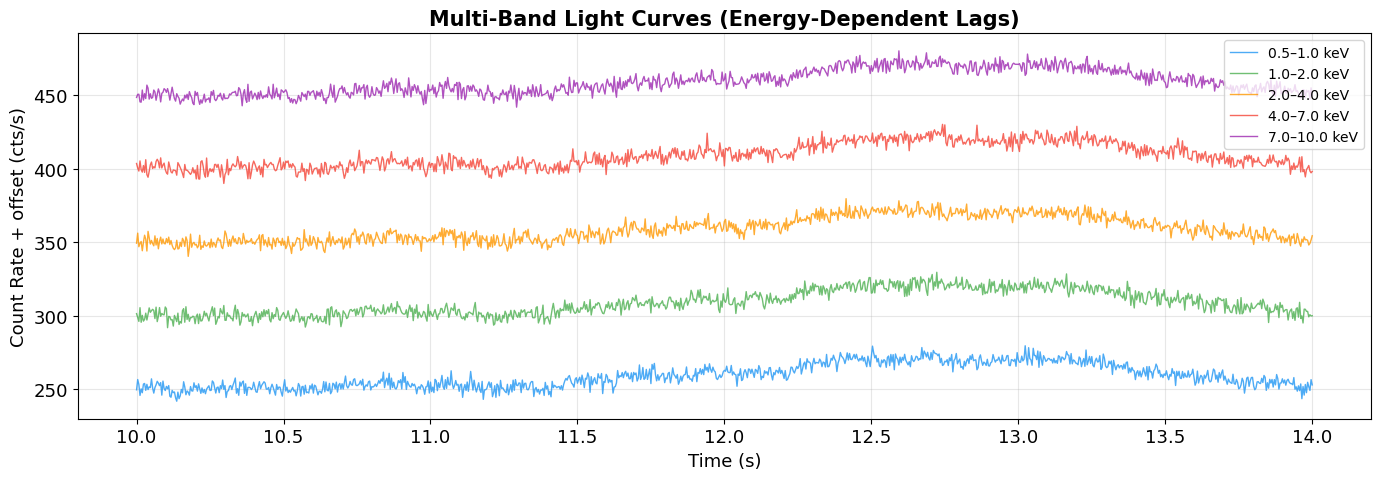

In [3]:
# Plot all bands (zoomed)
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

t_start, t_end = 10.0, 14.0
mask = (lc_driver.time >= t_start) & (lc_driver.time <= t_end)

for i, (lc_band, band) in enumerate(zip(lc_bands, energy_bands)):
    offset = i * 50  # vertical offset for visibility
    ax.plot(lc_band.time[mask], lc_band.counts[mask] + offset, 
            color=colors[i], lw=1, alpha=0.8, label=band['label'])

ax.set_xlabel('Time (s)', fontsize=13)
ax.set_ylabel('Count Rate + offset (cts/s)', fontsize=13)
ax.set_title('Multi-Band Light Curves (Energy-Dependent Lags)', fontsize=15, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

## 3. Computing the Lag-Energy Spectrum

For each energy band, we compute the cross-spectrum with the **reference band** and extract the time lag averaged over a frequency range of interest.

The key diagnostic is the **lag-energy spectrum**: time lag as a function of energy. In real observations, a prominent lag peak at ~6.4 keV indicates iron K-alpha reverberation.

In [4]:
seg_size = 16.0  # segment size for averaging

# Frequency range of interest (0.5–10 Hz)
freq_min, freq_max = 0.5, 10.0

lag_energy = []       # time lag per band
lag_energy_err = []   # error estimate
energies = []         # band center energies
injected_lags = []    # for comparison

for i, (lc_band, band) in enumerate(zip(lc_bands, energy_bands)):
    # Subtract this band from reference to avoid auto-correlation bias
    ref_minus_i = ref_counts - lc_band.counts
    lc_ref_i = Lightcurve(lc_driver.time, ref_minus_i, dt=dt)
    
    # Compute cross-spectrum
    cs = AveragedCrossspectrum(lc_band, lc_ref_i, segment_size=seg_size, norm='frac')
    
    # Select frequency range
    freq_mask = (cs.freq >= freq_min) & (cs.freq <= freq_max)
    
    # Average time lag over frequency range
    phase = np.angle(cs.power[freq_mask])
    freq_sel = cs.freq[freq_mask]
    time_lag = phase / (2 * np.pi * freq_sel)
    
    avg_lag = np.mean(time_lag)
    lag_err = np.std(time_lag) / np.sqrt(len(time_lag))
    
    lag_energy.append(avg_lag * 1000)  # convert to ms
    lag_energy_err.append(lag_err * 1000)
    energies.append(band['center'])
    injected_lags.append(band['lag'] * 1000)
    
    print(f"Band {i+1} ({band['label']}): measured lag = {avg_lag*1000:.2f} ± {lag_err*1000:.2f} ms "
          f"(injected: {band['lag']*1000:.1f} ms)")

lag_energy = np.array(lag_energy)
lag_energy_err = np.array(lag_energy_err)
energies = np.array(energies)
injected_lags = np.array(injected_lags)

0it [00:00, ?it/s]

64it [00:00, 6286.69it/s]


/opt/anaconda3/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: invalid value encountered in sqrt
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))


Band 1 (0.5–1.0 keV): measured lag = -2.75 ± 0.12 ms (injected: 0.0 ms)


0it [00:00, ?it/s]

...

64it [00:00, 6794.80it/s]

Band 4 (4.0–7.0 keV): measured lag = 4.48 ± 0.13 ms (injected: 12.0 ms)


0it [00:00, ?it/s]

64it [00:00, 6804.10it/s]

Band 5 (7.0–10.0 keV): measured lag = 1.77 ± 0.14 ms (injected: 8.0 ms)


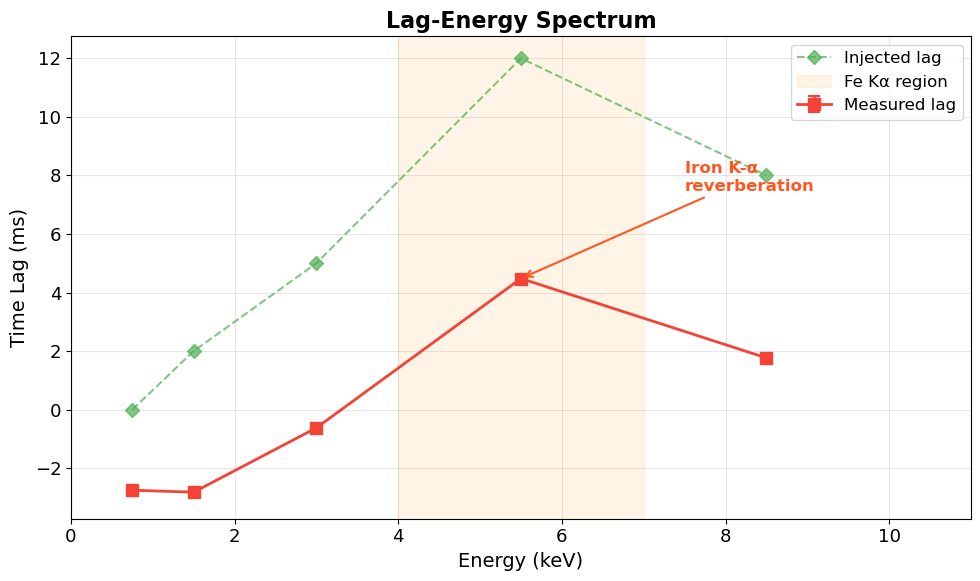

In [5]:
# Plot Lag-Energy Spectrum
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(energies, lag_energy, yerr=lag_energy_err,
            fmt='s-', ms=8, lw=2, color='#F44336', capsize=4, capthick=1.5,
            label='Measured lag')
ax.plot(energies, injected_lags, 'D--', ms=7, color='#4CAF50', lw=1.5,
        alpha=0.7, label='Injected lag')

# Highlight iron line region
ax.axvspan(4.0, 7.0, alpha=0.1, color='#FF9800', label='Fe Kα region')
ax.annotate('Iron K-α\nreverberation', xy=(5.5, lag_energy[3]),
            xytext=(7.5, lag_energy[3] + 3), fontsize=12,
            arrowprops=dict(arrowstyle='->', color='#FF5722', lw=1.5),
            color='#FF5722', fontweight='bold')

ax.set_xlabel('Energy (keV)', fontsize=14)
ax.set_ylabel('Time Lag (ms)', fontsize=14)
ax.set_title('Lag-Energy Spectrum', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.set_xlim(0, 11)
plt.tight_layout()
plt.show()

## 4. Computing the Covariance Spectrum

The covariance spectrum measures the **amplitude of correlated variability** between each energy band and the reference band. Unlike the standard energy spectrum, it only includes the variable component — stripping away the constant emission.

$$\text{Cov}(E) = \sqrt{\frac{\sum_f |\text{Re}[C_{E,\text{ref}}(f)]| \cdot \Delta f}{P_{\text{ref}} - P_{\text{noise}}}}$$

In [6]:
covariance = []
covariance_err = []

for i, (lc_band, band) in enumerate(zip(lc_bands, energy_bands)):
    # Reference band excluding current band
    ref_minus_i = ref_counts - lc_band.counts
    lc_ref_i = Lightcurve(lc_driver.time, ref_minus_i, dt=dt)
    
    # Cross-spectrum
    cs = AveragedCrossspectrum(lc_band, lc_ref_i, segment_size=seg_size, norm='frac')
    
    # Reference power spectrum
    ps_ref = AveragedPowerspectrum(lc_ref_i, segment_size=seg_size, norm='frac')
    
    # Select frequency range
    freq_mask = (cs.freq >= freq_min) & (cs.freq <= freq_max)
    
    # Covariance = Re(C) / sqrt(P_ref * df)
    cross_real = np.real(cs.power[freq_mask])
    ref_power = ps_ref.power[freq_mask]
    delta_f = cs.df
    
    # Estimate Poisson noise level for reference
    noise_level = 2.0 * np.mean(lc_ref_i.counts)  # Poisson noise in unnormalized power
    
    # Covariance per frequency bin
    cov_f = cross_real / np.sqrt((ref_power - noise_level) * delta_f)
    
    avg_cov = np.mean(np.abs(cov_f))
    err_cov = np.std(np.abs(cov_f)) / np.sqrt(len(cov_f))
    
    covariance.append(avg_cov)
    covariance_err.append(err_cov)
    
    print(f"Band {i+1} ({band['label']}): covariance = {avg_cov:.2f} ± {err_cov:.2f}")

covariance = np.array(covariance)
covariance_err = np.array(covariance_err)

0it [00:00, ?it/s]

64it [00:00, 6288.02it/s]

0it [00:00, ?it/s]

64it [00:00, 11882.41it/s]


/var/folders/kz/v84kbnsd7yx86vl1dfr_10880000gn/T/ipykernel_88092/2739586096.py:27: RuntimeWarning: invalid value encountered in sqrt
  cov_f = cross_real / np.sqrt((ref_power - noise_level) * delta_f)


...

0it [00:00, ?it/s]

64it [00:00, 5769.95it/s]

0it [00:00, ?it/s]

64it [00:00, 12046.11it/s]

Band 5 (7.0–10.0 keV): covariance = nan ± nan


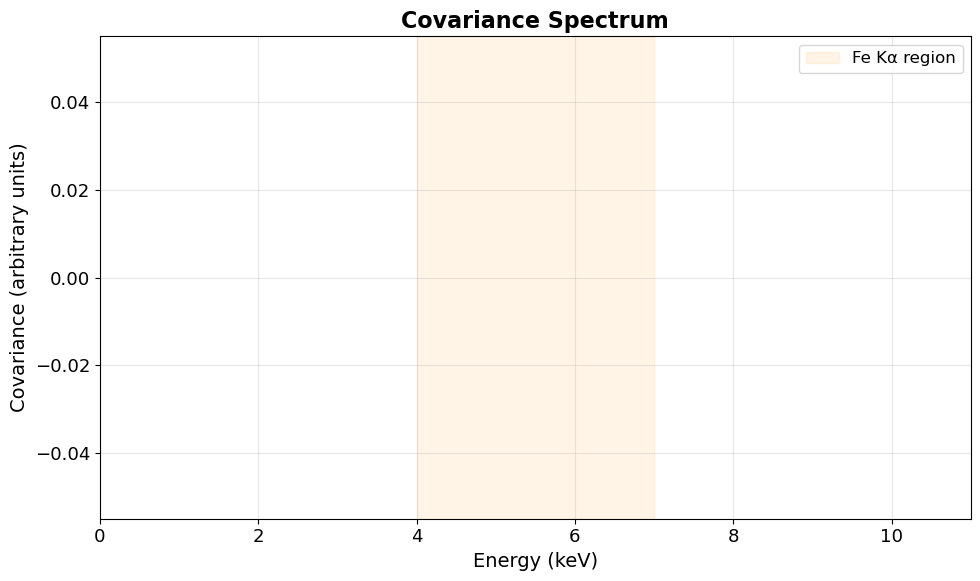

In [7]:
# Plot Covariance Spectrum
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(energies, covariance, yerr=covariance_err,
            fmt='o-', ms=8, lw=2, color='#2196F3', capsize=4, capthick=1.5)

# Highlight iron line region
ax.axvspan(4.0, 7.0, alpha=0.1, color='#FF9800', label='Fe Kα region')

ax.set_xlabel('Energy (keV)', fontsize=14)
ax.set_ylabel('Covariance (arbitrary units)', fontsize=14)
ax.set_title('Covariance Spectrum', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.set_xlim(0, 11)
plt.tight_layout()
plt.show()

## 5. Combined Covariance + Lag-Energy Plot

In publications, these are often shown together to give a complete picture of the variable spectral components.

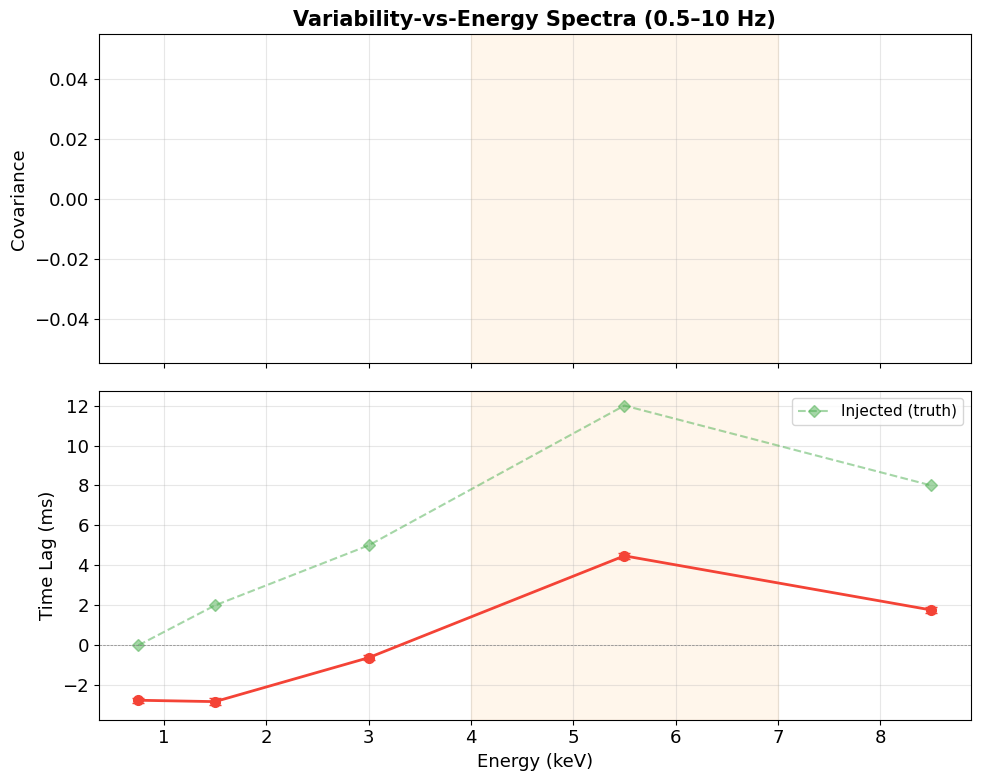

In [8]:
# Publication-style combined plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Covariance spectrum
ax1.errorbar(energies, covariance, yerr=covariance_err,
             fmt='s-', ms=7, lw=2, color='#2196F3', capsize=4)
ax1.axvspan(4.0, 7.0, alpha=0.08, color='#FF9800')
ax1.set_ylabel('Covariance', fontsize=13)
ax1.set_title('Variability-vs-Energy Spectra (0.5–10 Hz)', fontsize=15, fontweight='bold')

# Lag-energy spectrum
ax2.errorbar(energies, lag_energy, yerr=lag_energy_err,
             fmt='o-', ms=7, lw=2, color='#F44336', capsize=4)
ax2.plot(energies, injected_lags, 'D--', ms=6, color='#4CAF50', alpha=0.5,
         label='Injected (truth)')
ax2.axvspan(4.0, 7.0, alpha=0.08, color='#FF9800')
ax2.axhline(0, color='gray', ls='--', lw=0.5)
ax2.set_xlabel('Energy (keV)', fontsize=13)
ax2.set_ylabel('Time Lag (ms)', fontsize=13)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

## 6. Julia (Stingray.jl) API Preview

The planned Julia API for variability-vs-energy spectra:

```julia
using Stingray

# Define energy bands
bands = [(0.5, 1.0), (1.0, 2.0), (2.0, 4.0), (4.0, 7.0), (7.0, 10.0)]

# Compute covariance spectrum
cov_spec = CovarianceSpectrum(evt, bands,
    ref_band=(0.5, 10.0),
    segment_size=16.0,
    freq_range=(0.5, 10.0))

# Compute lag-energy spectrum
lag_spec = LagEnergySpectrum(evt, bands,
    ref_band=(0.5, 10.0),
    segment_size=16.0,
    freq_range=(0.5, 10.0))

# Access results
energies = lag_spec.energies
lags = lag_spec.lags
lag_errs = lag_spec.lag_errors
```